# Week 6 Day 2: Prediction Models — Match Winner & Top Player Models
### Goal:
Build the two core models that will later get wrapped as tools for the chat agent:
1. A match winner predictor (who wins, home/away, with a real probability)
2. A top player predictor (who's going to put up the best numbers)

Using tables from Day 1:
- `team_match_features_v1_2026-07-27.csv`
- `player_match_features_v1_2026-07-27.csv`

No re-deriving features from the raw files, Day 1 already locked those in.s

## Import and Setup

In [2]:
pip install matplotlib seaborn

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/bc/be/fa26ed085b41298f64a8f9b7592c671bbf1acc8b0df124c1c5de96b859f8/matplotlib-3.11.1-cp311-cp311-win_amd64.whl.metadata
     ---------------------------------------- 0.0/80.3 kB ? eta -:--:--
     -------------- ----------------------- 30.7/80.3 kB 660.6 kB/s eta 0:00:01
     -------------- ----------------------- 30.7/80.3 kB 660.6 kB/s eta 0:00:01
     -------------- ----------------------- 30.7/80.3 kB 660.6 kB/s eta 0:00:01
     ----------------------------- -------- 61.4/80.3 kB 297.7 kB/s eta 0:00:01
     -------------------------------------- 80.3/80.3 kB 344.9 kB/s eta 0:00:00
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Obtaining dependency information for contourpy


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: C:\Users\imama\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, brier_score_loss,mean_absolute_error, mean_squared_error, classification_report)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer


In [2]:
sns.set_style("whitegrid")
sns.set_palette("muted")
pd.set_option('display.max_columns', None)

team = pd.read_csv('team_match_features_v1_2026-07-27.csv')
player = pd.read_csv('player_match_features_v1_2026-07-27.csv')

#shape 
print("team_match_features_v1_2026-07-27.csv:", team.columns)
print("player_match_features_v1_2026-07-27.csv:", player.columns)


team_match_features_v1_2026-07-27.csv: Index(['team_name', 'opponent', 'match_date', 'year', 'round', 'venue',
       'home_away', 'result', 'team_win', 'recent_form_5', 'avg_score_last5',
       'win_streak_entering_match', 'days_rest', 'points_before_match',
       'ladder_position_before_match', 'h2h_win_rate_vs_opponent',
       'venue_win_rate'],
      dtype='str')
player_match_features_v1_2026-07-27.csv: Index(['player_id', 'team', 'opponent', 'match_date', 'year', 'round',
       'disposals', 'goals', 'fantasy_points', 'avg_disposals_last5',
       'avg_goals_last5', 'avg_fantasy_last5', 'player_name'],
      dtype='str')


#### Rearranging player_name

In [3]:
# Move player_name next to player_id
cols = player.columns.tolist()
cols.remove("player_name")
cols.insert(cols.index("player_id") + 1, "player_name")
player = player[cols]

# Check columns
print("team_match_features_v1_2026-07-27.csv:", team.columns)
print("player_match_features_v1_2026-07-27.csv:", player.columns)

team_match_features_v1_2026-07-27.csv: Index(['team_name', 'opponent', 'match_date', 'year', 'round', 'venue',
       'home_away', 'result', 'team_win', 'recent_form_5', 'avg_score_last5',
       'win_streak_entering_match', 'days_rest', 'points_before_match',
       'ladder_position_before_match', 'h2h_win_rate_vs_opponent',
       'venue_win_rate'],
      dtype='str')
player_match_features_v1_2026-07-27.csv: Index(['player_id', 'player_name', 'team', 'opponent', 'match_date', 'year',
       'round', 'disposals', 'goals', 'fantasy_points', 'avg_disposals_last5',
       'avg_goals_last5', 'avg_fantasy_last5'],
      dtype='str')


In [4]:
player

,player_id,player_name,team,opponent,match_date,year,round,disposals,goals,fantasy_points,avg_disposals_last5,avg_goals_last5,avg_fantasy_last5
0,43260,Jake Aarts,Richmond Tigers,Melbourne Demons,2020-07-05,2020,5,16.0,0.0,57,NaN,NaN,NaN
1,43260,Jake Aarts,Richmond Tigers,Sydney Swans,2020-07-12,2020,6,6.0,0.0,30,NaN,NaN,NaN
2,43260,Jake Aarts,Richmond Tigers,North Melbourne Kangaroos,2020-07-18,2020,7,8.0,2.0,46,11.00,0.000000,43.500000
3,43260,Jake Aarts,Richmond Tigers,Greater Western Sydney Giants,2020-07-24,2020,8,5.0,1.0,30,10.00,0.666667,44.333333
4,43260,Jake Aarts,Richmond Tigers,Western Bulldogs,2020-07-29,2020,9,7.0,3.0,52,8.75,0.750000,40.750000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
274084,46373,Ross Young,Carlton Blues,Fremantle Dockers,2007-06-30,2007,13,12.0,2.0,62,11.00,NaN,42.000000
274085,46373,Ross Young,Carlton Blues,Melbourne Demons,2007-07-08,2007,14,12.0,NaN,76,11.25,1.500000,47.000000
274086,46373,Ross Young,Carlton Blues,Sydney Swans,2007-07-15,2007,15,11.0,NaN,52,11.40,1.500000,52.800000
274087,46374,Will Young,Adelaide Crows,Sydney Swans,2010-04-04,2010,2,10.0,NaN,36,NaN,NaN,NaN


In [5]:
team

,team_name,opponent,match_date,year,round,venue,home_away,result,team_win,recent_form_5,avg_score_last5,win_streak_entering_match,days_rest,points_before_match,ladder_position_before_match,h2h_win_rate_vs_opponent,venue_win_rate
0,Adelaide Crows,hawthorn hawks,1991-03-22,1991,1,AAMI Stadium,H,W,1,NaN,NaN,0,NaN,0.0,1.0,NaN,NaN
1,Adelaide Crows,Carlton Blues,1991-03-31,1991,2,AAMI Stadium,H,L,0,NaN,NaN,1,9.0,4.0,1.0,NaN,1.000000
2,Adelaide Crows,Sydney Swans,1991-04-07,1991,3,Sydney Cricket Ground,A,W,1,NaN,NaN,-1,7.0,4.0,1.0,NaN,NaN
3,Adelaide Crows,Essendon Bombers,1991-04-13,1991,4,Windy Hill,A,L,0,0.666667,122.666667,1,6.0,8.0,1.0,NaN,NaN
4,Adelaide Crows,West Coast Eagles,1991-04-21,1991,5,Domain Stadium,A,L,0,0.500000,103.750000,-1,8.0,8.0,5.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15803,Western Bulldogs,essendon bombers,2025-07-25,2025,20,Marvel Stadium,A,W,1,0.600000,109.600000,-2,7.0,40.0,9.0,0.375000,0.524752
15804,Western Bulldogs,Greater Western Sydney Giants,2025-07-31,2025,21,Marvel Stadium,H,W,1,0.600000,111.200000,1,6.0,44.0,9.0,0.631579,0.526316
15805,Western Bulldogs,Melbourne Demons,2025-08-10,2025,22,Melbourne Cricket Ground,A,W,1,0.600000,116.600000,2,10.0,48.0,9.0,0.564516,0.452055
15806,Western Bulldogs,West Coast Eagles,2025-08-17,2025,23,Marvel Stadium,H,W,1,0.600000,110.800000,3,7.0,52.0,9.0,0.384615,0.527869


### Quick fix: Opponent name casing

Checked the `opponent` column in the team file and about 15% of rows have the team name in
lowercase (e.g. `hawthorn hawks` instead of `Hawthorn Hawks`). `team_name` is always proper case,
so this is a straightforward cleanup, map lowercase back to the proper name using `team_name`
as the source of truth. Same fix applied to `opponent` in the player file. This has to be fixed
before any merging, otherwise a `Hawthorn Hawks` home row won't match its `hawthorn hawks` away row.

In [6]:
canon = {name.lower(): name for name in team['team_name'].unique()}

print("Opponent values that were lowercase before fix:", team['opponent'].str.islower().sum())

team['opponent'] = team['opponent'].str.lower().map(canon)
player['opponent'] = player['opponent'].str.lower().map(lambda x: canon.get(x, x))

print("Opponent values that are lowercase after fix:", team['opponent'].str.islower().sum())
print("Any unmapped opponents left in team file:", team['opponent'].isnull().sum())
print("Any unmapped opponents left in player file:", player['opponent'].isnull().sum())

Opponent values that were lowercase before fix: 2345
Opponent values that are lowercase after fix: 0
Any unmapped opponents left in team file: 0
Any unmapped opponents left in player file: 0


## Building a match-level table

`team_match_features` has one row per team per match (so every match appears twice, once from each side). For the match winner model I need one row per match with both teams' features side by side, that's the actual unit being predicted on. So I'm merging the home team's row with its matching away team's row.

In [7]:
home = team[team['home_away'] == 'H'].copy()
away = team[team['home_away'] == 'A'].copy()

feat_cols = ['recent_form_5', 'avg_score_last5', 'win_streak_entering_match', 'days_rest',
             'points_before_match', 'ladder_position_before_match',
             'h2h_win_rate_vs_opponent', 'venue_win_rate']

home_r = home.rename(columns={c: 'home_' + c for c in feat_cols})
away_r = away.rename(columns={c: 'away_' + c for c in feat_cols})

matches = home_r.merge(
    away_r[['match_date', 'team_name', 'opponent'] + ['away_' + c for c in feat_cols]],
    left_on=['match_date', 'team_name', 'opponent'],
    right_on=['match_date', 'opponent', 'team_name'],
    suffixes=('', '_awayrow')
)
matches = matches.drop(columns=['team_name_awayrow', 'opponent_awayrow'])
matches = matches.rename(columns={'team_name': 'home_team', 'opponent': 'away_team'})
matches['match_date'] = pd.to_datetime(matches['match_date'])

print("Matches (should be roughly half of team rows):", matches.shape, "vs team rows:", team.shape)

Matches (should be roughly half of team rows): (7904, 25) vs team rows: (15808, 17)


### Handling draws for classification
Checking if draws affect our stuff

In [8]:
# draws don't fit a binary home/away winner label, dropping them for the classifier
# and noting how many that is
n_draws = (matches['result'] == 'D').sum()
print(f"Draws in the data: {n_draws} out of {len(matches)} matches ({n_draws/len(matches):.2%})")

matches = matches[matches['result'].isin(['W', 'L'])].copy()
matches['home_win_label'] = (matches['result'] == 'W').astype(int)
print("Matches after dropping draws:", matches.shape)

Draws in the data: 65 out of 7904 matches (0.82%)
Matches after dropping draws: (7839, 26)


**Draw handling:** AFL draws account for only 65 out of 7,904 matches (0.82%) in the dataset. Since the primary objective is to predict whether the home or away team wins, these matches were removed and the problem was framed as a binary classification task. This avoids introducing a third class with very limited training data while having minimal impact on the overall dataset.

## Task 1: Baseline Models
1. Match winner baseline
2. Top player baseline

## 1. Match winner baselines

Two baselines lets see:
1. Always predict home team wins (majority class, home teams win more often than not in AFL)
2. Higher-ladder team wins (using ladder_position_before_match, lower number = better ladder spot)
   
### Split Function from Day 1

In [9]:
def time_based_split(df, date_col='match_date', holdout_last_n_seasons=1, year_col='year'):
    """
    Splits a dataframe into train/holdout by season, not randomly.
    Holds out the most recent N seasons as the test set, trains on everything before that.
    Every model this week should call this function so all models see the exact same split.
    """
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])
    max_year = df[year_col].max()
    cutoff_year = max_year - holdout_last_n_seasons + 1

    train = df[df[year_col] < cutoff_year].copy()
    holdout = df[df[year_col] >= cutoff_year].copy()
    return train, holdout

#splitting----------------------------------------------
train_m, hold_m = time_based_split(matches)
print(f"Train: {train_m['year'].min()}-{train_m['year'].max()} ({len(train_m)} matches)")
print(f"Holdout: {hold_m['year'].min()}-{hold_m['year'].max()} ({len(hold_m)} matches)")

Train: 1983-2024 (7624 matches)
Holdout: 2025-2025 (215 matches)


### Match Winner Baseline 1: Always Predict Home Team Win
Using the split function, it should always predict home team wins

In [10]:
# Baseline 1: always predict home win
base1_pred = np.ones(len(hold_m))
base1_prob = np.full(len(hold_m), train_m['home_win_label'].mean())

print("MATCH WINNER BASELINE 1: Always predict home win")
print(f"Accuracy: {accuracy_score(hold_m['home_win_label'], base1_pred):.3f}")

print(f"F1: {f1_score(hold_m['home_win_label'], base1_pred):.3f}")

print(f"ROC AUC: {roc_auc_score(hold_m['home_win_label'], base1_prob):.3f}")

MATCH WINNER BASELINE 1: Always predict home win
Accuracy: 0.558
F1: 0.716
ROC AUC: 0.500


### Match Winner Baseline 2: Higher Ladder Team Wins
lower ladder num = better pos

In [11]:
# Baseline 2:(lower ladder number = better position) (RULE BASED)
base2_pred = (hold_m['home_ladder_position_before_match'] <= hold_m['away_ladder_position_before_match']).astype(int)

print("MATCH WINNER BASELINE 2: higher-ladder team wins")
print(f"Accuracy: {accuracy_score(hold_m['home_win_label'], base2_pred):.3f}")
print(f"F1: {f1_score(hold_m['home_win_label'], base2_pred):.3f}")
# print(f"ROC AUC: {roc_auc_score(hold_m['home_win_label'], base2_prob):.3f}")

MATCH WINNER BASELINE 2: higher-ladder team wins
Accuracy: 0.674
F1: 0.711


**Note:** Baseline 2 is a rule-based classifier that outputs only binary predictions (home team or away team), not probabilities. While ROC AUC can technically be computed from these binary outputs, it is less informative than for probabilistic models. The trained models later in the notebook will report probability-based ROC AUC using their predicted probabilities

#### Interpretation:
**Higher-ladder team wins at 67% accuracy** is already a decent baseline, better than always-home-win. Makes sense, ladder position captures a wholeseason of form. This is the bar the real model needs to clear. We are going with Higher Ladder Team Wins

## 2. Top player baseline
using **last week's leader repeats**, that were in the form of the rolling average, `avg_disposals_last5` predicts this match's disposals with a number the team already has (their own recent form). 

**Evaluating with MAE and a top-5 hit rate:** for each team in each match, does the actual top disposal-getter show up somewhere in the predicted top 5 (ranked by their rolling average)?

### MAE:
In ML MAE stands for Mean Absolute Error. It is an evaluation metric used to measure the accuracy of regression models. It calculates the average absolute distance between the model's predicted values and the actual target values

The lower the better

In [12]:
# Make sure match_date is stored as a datetime object for correct time-based splitting

player['match_date'] = pd.to_datetime(player['match_date'])
p_train, p_hold = time_based_split(player)

p_hold_b = p_hold.dropna(subset=['avg_disposals_last5', 'disposals']).copy()

baseline_mae = mean_absolute_error(p_hold_b['disposals'], p_hold_b['avg_disposals_last5'])
print(f"Baseline MAE (rolling avg predicts actual disposals): {baseline_mae:.2f}")

Baseline MAE (rolling avg predicts actual disposals): 4.04


An MAE of 4.04 on your rolling average baseline means the simple historical average is off by about 4 disposals per period.

### Top-K Accuracy
Top-k accuracy is an ML metric that measures if the correct answer is inside the top k highest-probability guesses made by a model. If k=5, a prediction counts as correct whenever the true label appears within the model's top 5 choices, making it useful for datasets with many similar classes.

In this case, Top-k accuracy means checking if the true top player of the match is included in my model's list of the top k predicted players

In [13]:
def topk_hitrate(df, pred_col, actual_col, k=5, group_cols=('team', 'match_date')):
    """For each team-match group, checks if the actual top performer is in the predicted top k."""
    hits, total = 0, 0
    for _, g in df.groupby(list(group_cols)):
        if len(g) < 2:
            continue
        actual_top = g.loc[g[actual_col].idxmax(), 'player_id']
        pred_top_ids = g.sort_values(pred_col, ascending=False).head(k)['player_id'].values
        hits += int(actual_top in pred_top_ids)
        total += 1
    return hits / total if total else np.nan

baseline_hitrate = topk_hitrate(p_hold_b, 'avg_disposals_last5', 'disposals', k=5)
print(f"Baseline top-5 hit rate: {baseline_hitrate:.3f}")

Baseline top-5 hit rate: 0.861


#### Interpretation

* Baseline top-5 hit rate is already pretty high (~86%), which makes sense, teams have about 19-23 players a game so top 5 is a fairly generous place, and disposal counts are sticky week to week as in good players stay good

* MAE of ~4 disposals is the number a real model needs to beat

## Task 2: Build the Match Winner Model

Building a preprocessing + model pipeline using the Day 1 team features (home and away versions of each). 
Training two model types:
* **Logistic Regression** and
* **Gradient Boosting**

### Features and Preprocessing pipeline

In [14]:
#numerical featues
num_feats = [
    'home_recent_form_5', 'home_avg_score_last5', 'home_win_streak_entering_match', 'home_days_rest',
    'home_points_before_match', 'home_ladder_position_before_match',
    'home_h2h_win_rate_vs_opponent', 'home_venue_win_rate',
    'away_recent_form_5', 'away_avg_score_last5', 'away_win_streak_entering_match', 'away_days_rest',
    'away_points_before_match', 'away_ladder_position_before_match',
    'away_h2h_win_rate_vs_opponent', 'away_venue_win_rate'
]



In [15]:
## training and holdout sets
X_train, y_train = train_m[num_feats], train_m['home_win_label']
X_hold, y_hold = hold_m[num_feats], hold_m['home_win_label']


In [16]:
#going for median imputation
preprocessor = ColumnTransformer([
    ('num', Pipeline(
        [('impute', SimpleImputer(strategy='median')),
         ('scale', StandardScaler())]), num_feats)
])


### Logistic Regression Pipeline

In [17]:

logreg_pipe = Pipeline(
    [('pre', preprocessor),
     ('clf', LogisticRegression(max_iter=1000,
    random_state=42))])



### Gradient Boosting Pipeline (classifier ofc)

In [18]:
gbm_pipe = Pipeline(
    [('pre', preprocessor),
     ('clf', GradientBoostingClassifier(random_state=42))
    ]
)


### Evaluation

In [19]:
results = []
for name, pipe in [('Logistic Regression', logreg_pipe), ('Gradient Boosting', gbm_pipe)]:
    
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_hold)
    prob = pipe.predict_proba(X_hold)[:, 1]
    
    results.append({
        'model': name,
        'accuracy': accuracy_score(y_hold, pred),
        'f1': f1_score(y_hold, pred),
        'roc_auc': roc_auc_score(y_hold, prob),
        'brier_score': brier_score_loss(y_hold, prob)
    })

results_df = pd.DataFrame(results)
results_df

,model,accuracy,f1,roc_auc,brier_score
0,Logistic Regression,0.697674,0.761905,0.752719,0.200290
1,Gradient Boosting,0.660465,0.730627,0.750439,0.199876


#### Comparing with Baseline 1 & 2 
Although: (Final Match winner baseline (higher ladder team)

In [20]:
comparison_df = pd.DataFrame({
    "Model": [
        "Baseline (Always Home Win)",
        "Baseline (Higher Ladder)",
        "Logistic Regression",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(hold_m["home_win_label"], base1_pred),
        accuracy_score(hold_m["home_win_label"], base2_pred),
        results_df.loc[results_df["model"] == "Logistic Regression", "accuracy"].iloc[0],
        results_df.loc[results_df["model"] == "Gradient Boosting", "accuracy"].iloc[0]
    ],
    "F1 Score": [
        f1_score(hold_m["home_win_label"], base1_pred),
        f1_score(hold_m["home_win_label"], base2_pred),
        results_df.loc[results_df["model"] == "Logistic Regression", "f1"].iloc[0],
        results_df.loc[results_df["model"] == "Gradient Boosting", "f1"].iloc[0]
    ],
    "ROC AUC": [
        roc_auc_score(hold_m["home_win_label"], base1_prob),
        np.nan,   # no probability estimates for this baseline
        results_df.loc[results_df["model"] == "Logistic Regression", "roc_auc"].iloc[0],
        results_df.loc[results_df["model"] == "Gradient Boosting", "roc_auc"].iloc[0]
    ],
    "Brier Score": [
        np.nan,
        np.nan,
        results_df.loc[results_df["model"] == "Logistic Regression", "brier_score"].iloc[0],
        results_df.loc[results_df["model"] == "Gradient Boosting", "brier_score"].iloc[0]
    ]
})

comparison_df

,Model,Accuracy,F1 Score,ROC AUC,Brier Score
0,Baseline (Always Home Win),0.558140,0.716418,0.500000,NaN
1,Baseline (Higher Ladder),0.674419,0.710744,NaN,NaN
2,Logistic Regression,0.697674,0.761905,0.752719,0.200290
3,Gradient Boosting,0.660465,0.730627,0.750439,0.199876


#### Interpretation:
Both machine learning models improved on the baselines. **Logistic Regression** achieved the best performance, with the highest **Accuracy (69.8%)**, **F1 Score (0.762)**, and **ROC AUC (0.753)**, indicating that it was the most effective at correctly predicting match winners and ranking win probabilities.
It was selected as the final model because it provided the strongest overall performance while remaining simple and interpretable.

As for **Brier Score:** Gradient Boosting's score is very tiny bit lower but that shouldnt cause any issues since Logistic Regression wins overall

The Higher Ladder Team baseline performed much better than always predicting a home win, showing that ladder position is a useful predictor of match outcomes.

### Calibration check

Brier score tells us how trustworthy the predicted probabilities are (lower is better, 0 is perfect). Since the agent is going to say things like "there's a 68% chance Team A wins", the probabilities need to actually mean something. It cant just get the label right, thats not enough

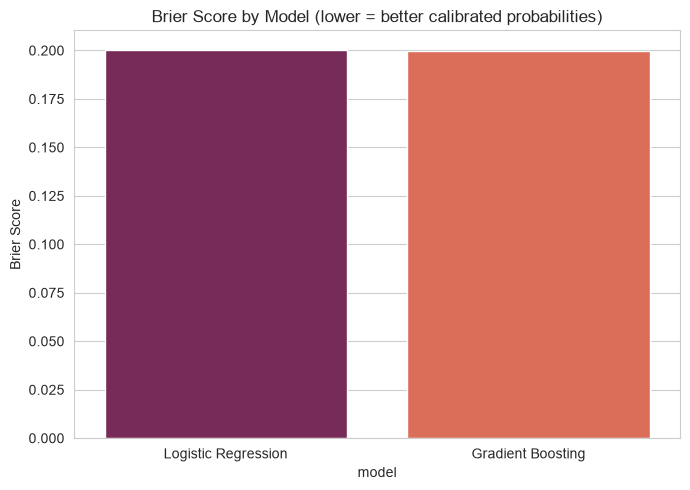

,model,accuracy,f1,roc_auc,brier_score
0,Logistic Regression,0.697674,0.761905,0.752719,0.200290
1,Gradient Boosting,0.660465,0.730627,0.750439,0.199876


In [21]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(data=results_df, x='model', y='brier_score', palette='rocket', ax=ax)
ax.set_title('Brier Score by Model (lower = better calibrated probabilities)')
ax.set_ylabel('Brier Score')
plt.tight_layout()
plt.show()

results_df

### Picking the final model

**Logistic Regression** comes out ahead on accuracy and F1, and it's basically tied with Gradient Boosting on ROC AUC and Brier score. Going with **Logistic Regression** as the final model for three reasons:

1. **Better on the metrics** here (accuracy, F1). It isnt just tied
2. **Fully interpretable**, every coefficient has a direct sign and size that a stakeholder can read, that matters a lot for something that's going to explain its picks through a chat agent
3. **Well calibrated already**, matching Gradient Boosting's Brier score without needing extra calibration wrapping (like `CalibratedClassifierCV`)

Gradient Boosting isn't clearly better here and it's more of a black box, so there's no actual reason to trade away the interpretability.

In [22]:
final_match_model = logreg_pipe  # already fit above
print("Final match winner model: Logistic Regression")
print(results_df[results_df['model'] == 'Logistic Regression'].to_string(index=False))

Final match winner model: Logistic Regression
              model  accuracy       f1  roc_auc  brier_score
Logistic Regression  0.697674 0.761905 0.752719      0.20029


## Task 3: Build the Top Player Model

### Framing: Regression, then Ranking

The top player task is framed as a **regression** problem, where the model predicts each player's expected stat value (disposals, goals, or fantasy points) for an upcoming match. Players are then ranked within each team-match based on the predicted values to identify the top performers.

Regression was chosen over a learning-to-rank approach because the predicted stat values are useful on their own (e.g., "expected to record around 24 disposals"), while also naturally producing a ranking. Separate models will be trained for **disposals**, **goals**, and **fantasy points**, using each player's rolling averages as the input features.

Going to use GradientBoostRegressor for it

In [23]:
player_feats = ['avg_disposals_last5', 'avg_goals_last5', 'avg_fantasy_last5']
stat_targets = ['disposals', 'goals', 'fantasy_points']

In [24]:
player_models = {}
player_eval_rows = []

for target in stat_targets:
    tr = p_train.dropna(subset=player_feats + [target])   #train
    ho = p_hold.dropna(subset=player_feats + [target])  #holdout

    pre = ColumnTransformer([
        ('num', Pipeline([
            ('impute', SimpleImputer(strategy='median')),
            ('scale', StandardScaler())]), player_feats)
    ])

    # making the pipeline
    
    model = Pipeline([('pre', pre),
                      ('reg', GradientBoostingRegressor(random_state=42))
                     ])
    #fitting
    model.fit(tr[player_feats], tr[target])

    #eval
    pred = model.predict(ho[player_feats])
    mae = mean_absolute_error(ho[target], pred)
    rmse = mean_squared_error(ho[target], pred) ** 0.5

    ho = ho.copy()
    ho['pred'] = pred
    hitrate = topk_hitrate(ho, 'pred', target, k=5)

    player_models[target] = model
    player_eval_rows.append({'stat': target,
                             'mae': mae,
                             'rmse': rmse,
                             'top5_hit_rate': hitrate,
                             'n_holdout': len(ho)})

player_eval_df = pd.DataFrame(player_eval_rows)
player_eval_df

,stat,mae,rmse,top5_hit_rate,n_holdout
0,disposals,3.816555,4.901481,0.981481,4422
1,goals,0.754343,1.039934,0.944316,2371
2,fantasy_points,18.177515,22.761356,0.891204,4567


In [25]:
print("Comparison against Task 1 baseline (disposals):")
print(f"  Baseline MAE: {baseline_mae:.2f}  |  Model MAE: {player_eval_df.loc[player_eval_df.stat=='disposals','mae'].values[0]:.2f}")
print(f"  Baseline top-5 hit rate: {baseline_hitrate:.3f}  |  Model top-5 hit rate: {player_eval_df.loc[player_eval_df.stat=='disposals','top5_hit_rate'].values[0]:.3f}")


Comparison against Task 1 baseline (disposals):
  Baseline MAE: 4.04  |  Model MAE: 3.82
  Baseline top-5 hit rate: 0.861  |  Model top-5 hit rate: 0.981


### Compare to the baseline

The model is indeed meaningfully better

**Baseline** was:

MAE: 4.04
Top-5 Hit Rate: 0.861

For **disposals**, the model achieved:

MAE = 3.82, which is lower than the baseline (lower is better), so the regression model predicts disposals more accurately than simply using the rolling average.
Since the model's hit rate is higher than the baseline, it also improved at identifying the team's top disposal-getter

#### Interpretation by stat:

**Disposals**:

The disposals model achieved the best overall performance, with a low MAE of 3.82 and a Top-5 Hit Rate of 98.1%. It also outperformed the rolling-average baseline, making it the strongest player prediction model.

**Goals:**

The goals model achieved an MAE of 0.75, meaning its predictions were typically within about one goal of the actual result. It also achieved a high Top-5 Hit Rate of 94.4%, showing it can reliably identify the leading goal scorers.

**Fantasy Points:**

The fantasy points model achieved an MAE of 18.18 and a Top-5 Hit Rate of 89.1%. Although fantasy points are more variable because they combine many different statistics, the model was still able to rank the top performers effectively.

**Final Interpretation:**
The **disposals** model beats the baseline on both counts, lower MAE and a noticeably better top-5 hit rate (adding goals and fantasy trend as extra features on top of just the disposals rolling average gives the model more to work with). It's not just noise, MAE dropped by about **half a disposal** and hit rate jumped from **86% to 98%**

#### Final top player model: **Gradient Boosting Regressor**
one fit per stat type (disposals, goals, fantasy_points), all using the same three rolling-average features.

## Task 4: Feature Importance and Sanity Checks

### Match winner model coefficients

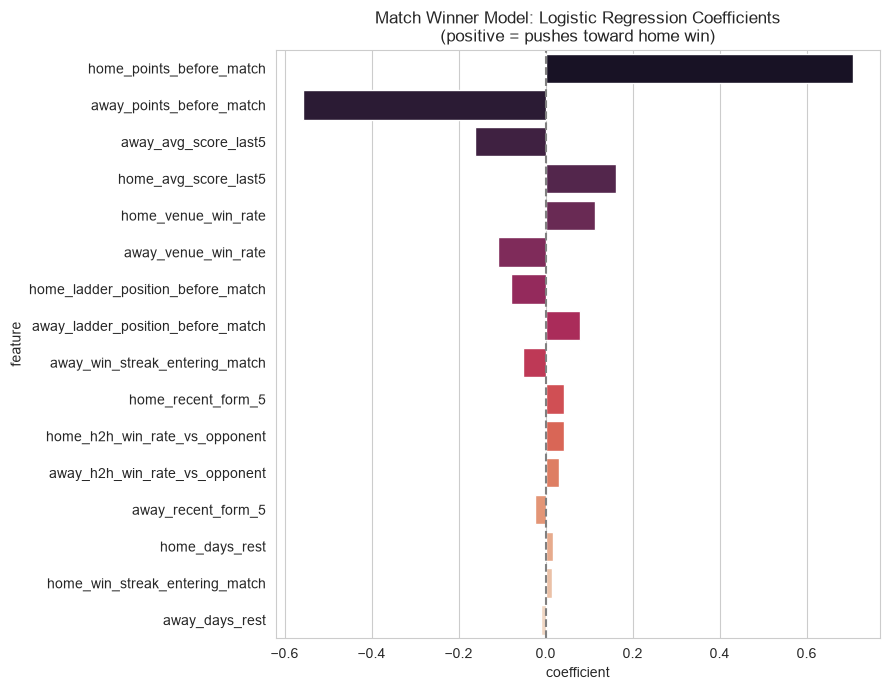

,feature,coefficient
4,home_points_before_match,0.705578
12,away_points_before_match,-0.557144
9,away_avg_score_last5,-0.162167
1,home_avg_score_last5,0.161300
7,home_venue_win_rate,0.113741
15,away_venue_win_rate,-0.110073
5,home_ladder_position_before_match,-0.079510
13,away_ladder_position_before_match,0.078741
10,away_win_streak_entering_match,-0.052214
0,home_recent_form_5,0.043120


In [26]:
log_clf = final_match_model.named_steps['clf']
coefs = pd.DataFrame({
    'feature': num_feats,
    'coefficient': log_clf.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(data=coefs, y='feature', x='coefficient', palette='rocket', ax=ax)
ax.axvline(0, color='gray', linestyle='--')
ax.set_title('Match Winner Model: Logistic Regression Coefficients\n(positive = pushes toward home win)')
plt.tight_layout()
plt.show()

coefs

#### Interpretation

* **Points before the match** (home and away) had the largest influence, making them the strongest predictors of the match outcome.
* **Average score over the last 5 games** and **venue win rate** were also important, showing that recent form and home-ground advantage matter.
* **Recent form, head-to-head record, win streak, and days of rest** had smaller effects but still contributed to the predictions.

The top features all make football sense, and none appear to indicate data leakage.


### Top player model feature importances (disposals)

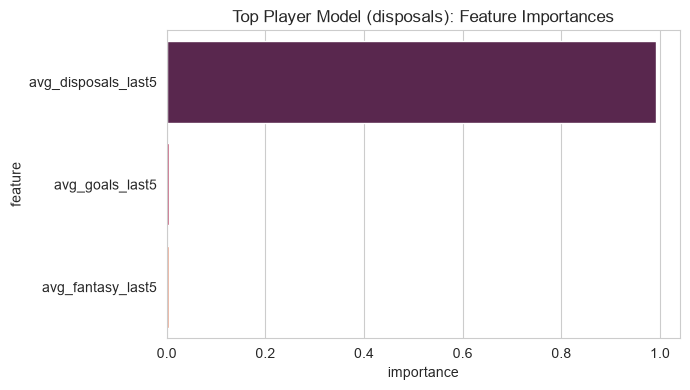

,feature,importance
0,avg_disposals_last5,0.990963
1,avg_goals_last5,0.004920
2,avg_fantasy_last5,0.004117


In [27]:
gbm_reg = player_models['disposals'].named_steps['reg']
importances = pd.DataFrame({
    'feature': player_feats,
    'importance': gbm_reg.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=importances, y='feature', x='importance', palette='rocket', ax=ax)
ax.set_title('Top Player Model (disposals): Feature Importances')
plt.tight_layout()
plt.show()

importances

#### Interpretation:
`avg_disposals_last5` dominates, which is exactly what should happen, since this is about disposals.

A player's own recent disposal count is the single best predictor of their next one. Goals and fantasy trend add a bit of extra signal on top but aren't doing the heavy lifting. No leakage here either


### Sniff test: 3 holdout matches

Picking 3 matches from the 2025 holdout season, reasoning through what is expected based on the raw numbers, then checking what the model actually predicted.

In [28]:
sniff_sample = hold_m.sample(3, random_state=7)[
    ['home_team', 'away_team', 'match_date', 'home_recent_form_5', 'away_recent_form_5',
     'home_ladder_position_before_match', 'away_ladder_position_before_match', 'home_win_label']
].copy()

sniff_X = hold_m.loc[sniff_sample.index, num_feats]
sniff_sample['model_home_win_prob'] = final_match_model.predict_proba(sniff_X)[:, 1]
sniff_sample['actual_result'] = np.where(sniff_sample['home_win_label'] == 1, 'home_win', 'away_win')

sniff_sample

,home_team,away_team,match_date,home_recent_form_5,away_recent_form_5,home_ladder_position_before_match,away_ladder_position_before_match,home_win_label,model_home_win_prob,actual_result
5144,North Melbourne Kangaroos,Collingwood Magpies,2025-05-24,0.2,0.8,17.0,1.0,0,0.249390,away_win
2828,Fremantle Dockers,Collingwood Magpies,2025-05-08,0.6,0.8,8.0,2.0,0,0.479824,away_win
3503,Gold Coast Suns,Brisbane Lions,2025-07-26,0.6,0.8,8.0,2.0,1,0.455361,home_win


### Interpretation

* **Match 1:** Collingwood had much better recent form (0.8 vs 0.2) and a much higher ladder position (1st vs 17th), so an away win was expected. The model gave the home team only a **24.9%** chance of winning, matching the actual result.
* **Match 2:** Collingwood again had stronger recent form and ladder position, so an away win was expected. The model predicted a fairly even game (**48.0%** home win probability) but still slightly favored the away team, which matched the actual outcome.
* **Match 3:** Brisbane entered with the stronger form and ladder position, so an away win seemed more likely. However, Gold Coast won despite the model giving them only a **45.5%** chance, showing that unexpected results can still happen in sport and do not necessarily indicate a problem with the model

**Disagreements**: The 3rd match is the disagreement, and the explanation is simply that sports are inherently unpredictable rather than there being evidence of leakage or a faulty model


## Task 5: Package Models as Callable Functions

Saving both pipelines and building wrapper functions with input validation. The full versions with docstrings and error handling live in `predict.py`, saved separately as the module that'll get imported by the agentic tools later.

Below is thesave step and a quick smoke test of the interface.

### Saving the trained models

The trained models were saved as .joblib files so they can be loaded later without retraining. This makes them easy to reuse in the prediction functions and later wrap as tools for the chat assistant

**Saved models:**
- `match_winner_model.joblib`: final Logistic Regression pipeline for predicting the match winner.
- `top_player_model_disposals.joblib`: Gradient Boosting Regressor for predicting player disposals.
- `top_player_model_goals.joblib`: Gradient Boosting Regressor for predicting player goals.
- `top_player_model_fantasy_points.joblib`: Gradient Boosting Regressor for predicting player fantasy points.
- `latest_team_features.joblib`: latest available team features used to make match winner predictions.
- `latest_player_features.joblib`: latest available player features used to make top player predictions.
- `valid_teams.joblib`: list of valid AFL team names used for input validation.


In [29]:
# match winner model
joblib.dump(final_match_model, 'models/match_winner_model.joblib')

['models/match_winner_model.joblib']

In [30]:
# all 3 top player models
joblib.dump(final_match_model, 'match_winner_model.joblib')
for stat, model in player_models.items():
    joblib.dump(model, f'models/top_player_model_{stat}.joblib')

In [31]:
# also saving small lookup tables the predict functions need: latest known features per team/player
latest_team_features = (
    team.sort_values('match_date')
    .groupby('team_name')
    .tail(1)[['team_name'] + feat_cols]
    .reset_index(drop=True)
)
latest_player_features = (
    player.sort_values('match_date')
    .groupby('player_id')
    .tail(1)[['player_id', 'player_name', 'team'] + player_feats]
    .reset_index(drop=True)
)

joblib.dump(latest_team_features, 'models/latest_team_features.joblib')
joblib.dump(latest_player_features, 'models/latest_player_features.joblib')


#valid teams
joblib.dump(sorted(team['team_name'].unique().tolist()), 'models/valid_teams.joblib')


['models/valid_teams.joblib']

### Predict.py Workflow
```
User
   │
   ▼
predict_match_winner()
   │
   ├── Check team names
   ├── Load latest team features
   ├── Build feature row
   ├── Run Logistic Regression model
   └── Return winner + probability


User
   │
   ▼
predict_top_player()
   │
   ├── Check inputs
   ├── Load latest player features
   ├── Run Gradient Boosting model
   ├── Rank players
   └── Return Top N players

```

### How to call each model

**Match winner:**
```python
from predict import predict_match_winner
predict_match_winner("Richmond Tigers", "Carlton Blues")
# -> {'home_team': 'Richmond Tigers', 'away_team': 'Carlton Blues',
#     'winner': 'Richmond Tigers', 'home_win_probability': 0.63}
```

**Top player:**
```python
from predict import predict_top_player
predict_top_player("Richmond Tigers", stat_type="disposals", top_n=5)
# -> [{'player_name': '....', 'predicted_disposals': 27.4}, .....]
```

Both functions use each team's/player's most recent known rolling features (saved above) as the "current state" going into the prediction, since there's no live upcoming-fixture feed plugged in yet. That'll be the natural place to swap in real fixture data once the agent is wired up

In [32]:
import sys
sys.path.insert(0, '.')
# quick smoke test of the actual module
import importlib
if 'predict' in sys.modules:
    importlib.reload(sys.modules['predict'])
import predict
print(predict.predict_match_winner("Richmond Tigers", "Carlton Blues"))
print("\n", predict.predict_top_player("Richmond Tigers", stat_type="disposals", top_n=5))

{'home_team': 'Richmond Tigers', 'away_team': 'Carlton Blues', 'winner': 'Carlton Blues', 'home_win_probability': 0.412}

 [{'player_name': 'Jacob Hopper', 'predicted_disposals': 26.3}, {'player_name': 'Kane Johnson', 'predicted_disposals': 24.0}, {'player_name': 'Tim Taranto', 'predicted_disposals': 24.0}, {'player_name': 'Ben Cousins', 'predicted_disposals': 22.7}, {'player_name': 'Joel Bowden', 'predicted_disposals': 22.5}]


### Basic Input Validation

In [33]:
# input validation smoke test, unknown team name should raise a clear error
try:
    predict.predict_match_winner("Richmond Tigers", "Fake Team FC")
except ValueError as e:
    print("Correctly caught bad input:", e)

Correctly caught bad input: Unknown team 'Fake Team FC'. Valid team names are: Adelaide Crows, Brisbane Bears, Brisbane Lions, Carlton Blues, Collingwood Magpies, Essendon Bombers, Fitzroy Lions, Fremantle Dockers, Geelong Cats, Gold Coast Suns, Greater Western Sydney Giants, Hawthorn Hawks, Melbourne Demons, North Melbourne Kangaroos, Port Adelaide Power, Richmond Tigers, St Kilda Saints, Sydney Swans, West Coast Eagles, Western Bulldogs


## Summary

- Built a match-level dataset by combining the home and away team rows from the Day 1 feature table.
- Created baseline models for both match winner and top player predictions to compare against.
- Trained two match winner models, with **Logistic Regression** performing the best (69.8% accuracy, 0.753 ROC AUC).
- Trained **Gradient Boosting Regressor** models for disposals, goals, and fantasy points. The disposals model improved on the baseline (MAE: **3.82 vs 4.04**, Top-5 Hit Rate: **98% vs 86%**).
- Checked feature importance and confirmed the top features made football sense, with no signs of data leakage.
- Ran a sniff test on three holdout matches, and the predictions were mostly in line with expectations.
- Saved the trained models and lookup tables as `.joblib` files, ready to be used by the prediction functions and chat agent later.

Note: you may need to restart the kernel to use updated packages.
